In [70]:
import numpy as np
import matplotlib.pyplot as plt
import legume
from legume import Circle, Ring

# L3 Cavity with Oxidized Holes
Optimized L3 cavity (GaAs, end-hole shift from autograd optimization) with
thin oxide rings on hole sidewalls. Sweeps oxide thickness to study effect on Q.

Bandgap: 0.2489 – 0.3274,  centre f_target = 0.2882


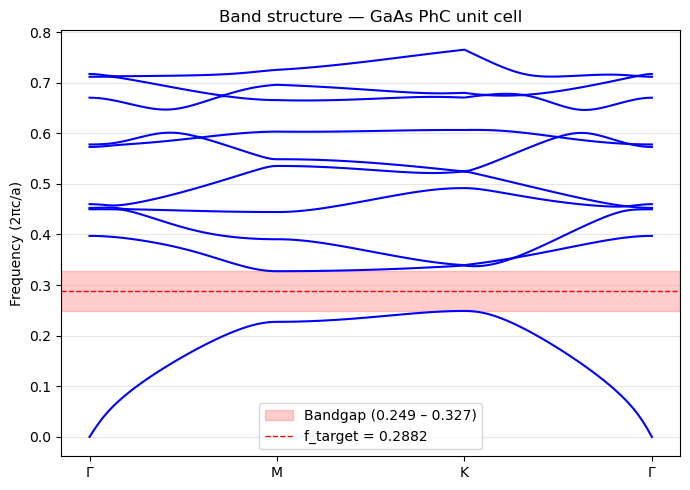

In [71]:
# ── Band structure of the perfect PhC (unit cell) ──────────────────────────

# ── Physical parameters ─────────────────────────────────────────────────────
a_nm = 250              # lattice constant in nm
ra = 75 / a_nm          # hole radius in units of a
dslab = 170 / a_nm      # slab thickness in units of a
n_slab = 3.46           # refractive index (GaAs)

lattice_unit = legume.Lattice('hexagonal')
phc_unit = legume.PhotCryst(lattice_unit)
phc_unit.add_layer(d=dslab, eps_b=n_slab**2)
phc_unit.add_shape(Circle(x_cent=0, y_cent=0, r=ra))

path_dict = lattice_unit.bz_path(['G', 'M', 'K', 'G'], [40, 40, 40])
kpoints = path_dict['kpoints']

gme_bands = legume.GuidedModeExp(phc_unit, gmax=3.0, truncate_g='tbt')
gme_bands.run(kpoints=kpoints, gmode_inds=[0], verbose=False, numeig=10)

# Find the largest complete bandgap
freqs_b = gme_bands.freqs
f_lb, f_ub, f_target = None, None, None
best_gap = 0
for i in range(freqs_b.shape[1] - 1):
    top = np.max(freqs_b[:, i])
    bot = np.min(freqs_b[:, i + 1])
    if bot > top and (bot - top) > best_gap:
        best_gap = bot - top
        f_lb, f_ub = top, bot
        f_target = (top + bot) / 2

print(f'Bandgap: {f_lb:.4f} \u2013 {f_ub:.4f},  centre f_target = {f_target:.4f}')

# Plot band structure
fig, ax = plt.subplots(figsize=(7, 5))
for i in range(freqs_b.shape[1]):
    ax.plot(freqs_b[:, i], 'b-', lw=1.5)
ax.axhspan(f_lb, f_ub, alpha=0.2, color='red',
           label=f'Bandgap ({f_lb:.3f} \u2013 {f_ub:.3f})')
ax.axhline(f_target, color='red', ls='--', lw=1,
           label=f'f_target = {f_target:.4f}')
ax.set_xticks([0, 40, 80, 120])
ax.set_xticklabels(['\u0393', 'M', 'K', '\u0393'])
ax.set_ylabel('Frequency (2\u03c0c/a)')
ax.set_title('Band structure \u2014 GaAs PhC unit cell')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [72]:
# ── Supercell parameters ───────────────────────────────────────────────────
Nx, Ny = 16, 10

# Oxide material
n_oxide = 1.72
eps_oxide = n_oxide**2

# Initialize supercell lattice
lattice = legume.Lattice([Nx, 0], [0, Ny*np.sqrt(3)/2])

# Build hole positions in one quadrant (L3: skip ix=0,1 at iy=0)
xp, yp = [], []
nx, ny = Nx//2 + 1, Ny//2 + 1
for iy in range(ny):
    for ix in range(nx):
        if iy == 0 and ix in (0, 1):
            continue
        xp.append(ix + (iy%2)*0.5)
        yp.append(iy*np.sqrt(3)/2)

nc = len(xp)

# Optimized end-hole shift (from autograd optimization notebook)
dx_opt = 0.17964
dx = np.zeros(nc)
dy = np.zeros(nc)
dx[0] = dx_opt  # ic=0 → end holes at (±2, 0)

print(f'nc = {nc} holes per quadrant')
print(f'Optimized end-hole shift: dx[0] = {dx_opt}a = {dx_opt * a_nm:.1f} nm')

nc = 52 holes per quadrant
Optimized end-hole shift: dx[0] = 0.17964a = 44.9 nm


In [73]:
def cavity_oxidized(t_ox_nm, consume_ratio=0.5, r_nm=None):
    """Build an L3 cavity with oxide on ALL exposed surfaces.

    Oxide grows both into the GaAs (consuming it) and outward (adding volume).
    The consume_ratio controls the split, applied to both top/bottom surfaces
    and hole sidewalls.

    Parameters
    ----------
    t_ox_nm : float
        Total oxide thickness in nm. Set to 0 for unoxidized cavity.
    consume_ratio : float, optional
        Fraction of oxide that replaces GaAs (0–1). Default 0.5.
        0 = all oxide added as extra volume (no GaAs consumed).
        1 = all oxide replaces GaAs (no extra volume added).
    r_nm : float or None, optional
        Hole radius in nm. If None, uses the global `ra` (75 nm default).
    """
    t_ox = t_ox_nm / a_nm  # nm → normalized units
    r_a = (r_nm / a_nm) if r_nm is not None else ra

    if t_ox_nm > 0:
        d_consume = consume_ratio * t_ox
        d_slab_eff = dslab - 2 * d_consume
        if d_slab_eff <= 0:
            raise ValueError(
                f'Oxide consumes entire slab: 2*{consume_ratio}*{t_ox_nm} nm '
                f'>= dslab = {dslab * a_nm} nm')
        r_outer = r_a + consume_ratio * t_ox
        r_inner = r_a - (1 - consume_ratio) * t_ox
    else:
        d_slab_eff = dslab

    phc = legume.PhotCryst(lattice)

    if t_ox_nm > 0:
        # Layer 0: bottom oxide film
        phc.add_layer(d=t_ox, eps_b=eps_oxide)
        # Layer 1: thinned GaAs slab
        phc.add_layer(d=d_slab_eff, eps_b=n_slab**2)
        # Layer 2: top oxide film
        phc.add_layer(d=t_ox, eps_b=eps_oxide)
    else:
        # No oxide: single slab layer (layer 0)
        phc.add_layer(d=dslab, eps_b=n_slab**2)

    slab_idx = 1 if t_ox_nm > 0 else 0

    for ic in range(nc):
        yc = yp[ic]
        xc = xp[ic] + dx[ic] if xp[ic] != 0 else 0.0

        positions = [(xc, yc)]
        if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
            positions.append((-xc, -yc))
        if nx-1.6 > xp[ic] > 0:
            positions.append((-xc, yc))
        if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
            positions.append((xc, -yc))

        for (px, py) in positions:
            if t_ox_nm > 0:
                # Slab layer: oxide ring (consumes GaAs + grows into air)
                phc.add_shape(Ring(eps=eps_oxide, r_i=r_inner, r_o=r_outer,
                                  x_cent=px, y_cent=py), layer=slab_idx)
                phc.add_shape(Circle(eps=1.0, r=r_inner,
                                    x_cent=px, y_cent=py), layer=slab_idx)
                # Oxide layers: air holes punch through
                phc.add_shape(Circle(eps=1.0, r=r_outer,
                                    x_cent=px, y_cent=py), layer=0)
                phc.add_shape(Circle(eps=1.0, r=r_outer,
                                    x_cent=px, y_cent=py), layer=2)
            else:
                phc.add_shape(Circle(x_cent=px, y_cent=py, r=r_a))

    return phc

## Visualize structure

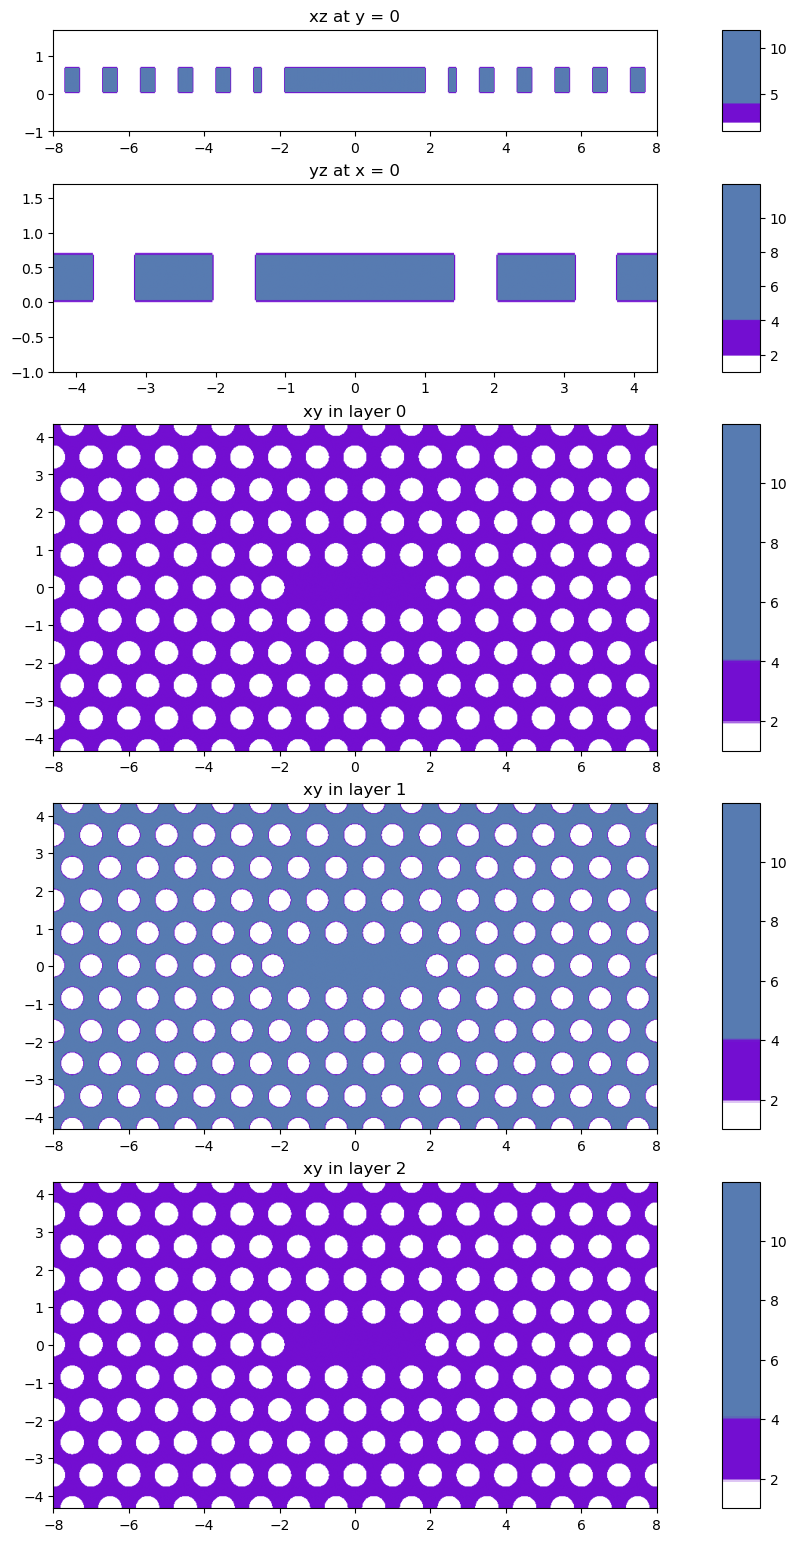

In [74]:
# Visualize the oxidized cavity (t_ox = 5 nm)
phc_viz = cavity_oxidized(5.0)
gme_viz = legume.GuidedModeExp(phc_viz, gmax=2, truncate_g='tbt')

# Discrete colormap: air=white, oxide=gold, GaAs=dark blue
# eps values: air=1.0, oxide~2.96, GaAs~11.97
# Normalized positions in [min_eps, max_eps] = [1, 12]: oxide at ~0.18
import matplotlib.colors as mcolors
cmap_discrete = mcolors.LinearSegmentedColormap.from_list('discrete_eps', [
    (0.00, 'white'),     # air
    (0.08, 'white'),
    (0.09, "#730ed1"),   # oxide
    (0.27, '#730ed1'),
    (0.28, "#577bb1"),   # GaAs
    (1.00, '#577bb1')
])

legume.viz.structure(phc_viz, xz=True, yz=True, figsize=8, cmap=cmap_discrete,
                     Nx=800, Ny=500, Nz=100)
#legume.viz.eps_ft(gme_viz, Nx=200, Ny=200, figsize=4, cbar=True, cmap='BuPu')

## Baseline: unoxidized L3 cavity

11.913s total time for real part of frequencies in GuidedModeExp, of which
  0.114s (1%) for guided modes computation using the gmode_compute='exact' method
  0.857s (7%) for inverse matrix of Fourier-space permittivity
  9.300s (78%) for matrix diagionalization using the 'eigh' solver
  1.641s (14%) for creating GME matrix
Skipping imaginary part computation, use run_im() to run it, or compute_rad() to compute the radiative rates of selected eigenmodes

Modes near bandgap centre (bandgap: 0.2489 – 0.3274):
  Mode 0: f = 0.25754,  Q = 198852.0 <-- IN BANDGAP
  Mode 1: f = 0.27028,  Q = 5372.3 <-- IN BANDGAP
  Mode 2: f = 0.27955,  Q = 726.8 <-- IN BANDGAP
  Mode 3: f = 0.28162,  Q = 253.8 <-- IN BANDGAP
  Mode 4: f = 0.28371,  Q = 274.2 <-- IN BANDGAP
  Mode 5: f = 0.29405,  Q = 1853.0 <-- IN BANDGAP
  Mode 6: f = 0.31682,  Q = 1324.3 <-- IN BANDGAP
  Mode 7: f = 0.31761,  Q = 4816.1 <-- IN BANDGAP
  Mode 8: f = 0.31990,  Q = 8921.6 <-- IN BANDGAP
  Mode 9: f = 0.32488,  Q = 2361.7 <--

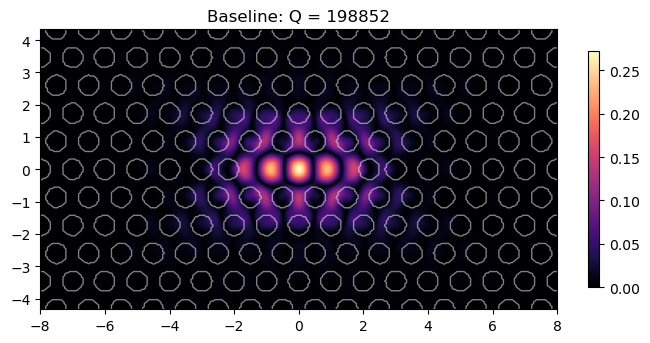

In [75]:
gmax = 2
truncate_g = 'tbt'
options = {'gmode_inds': [0], 'verbose': True, 'numeig': 10,
           'eig_sigma': f_target, 'gradients': 'approx', 'compute_im': False}

# Unoxidized cavity
phc_base = cavity_oxidized(0)
gme_base = legume.GuidedModeExp(phc_base, gmax=gmax, truncate_g=truncate_g)
gme_base.run(kpoints=np.array([[0], [0]]), **options)

# Identify the L3 cavity mode (first mode in bandgap)
print(f'\nModes near bandgap centre (bandgap: {f_lb:.4f} \u2013 {f_ub:.4f}):')
mode_idx = None
for i in range(gme_base.freqs.shape[1]):
    (freq_im_i, _, _) = gme_base.compute_rad(0, [i])
    Qi = gme_base.freqs[0, i] / (2 * freq_im_i[0])
    in_gap = f_lb < gme_base.freqs[0, i] < f_ub
    tag = ' <-- IN BANDGAP' if in_gap else ''
    print(f'  Mode {i}: f = {gme_base.freqs[0, i]:.5f},  Q = {Qi:.1f}{tag}')
    if in_gap and mode_idx is None:
        mode_idx = i

if mode_idx is None:
    raise RuntimeError('No mode found inside the bandgap')

(freq_im, _, _) = gme_base.compute_rad(0, [mode_idx])
Q_base = gme_base.freqs[0, mode_idx] / (2 * freq_im[0])
f_base = gme_base.freqs[0, mode_idx]
print(f'\nBaseline (no oxide): mode_idx = {mode_idx}, f = {f_base:.5f}, Q = {Q_base:.1f}')

ax = legume.viz.field(gme_base, 'e', 0, mode_idx, z=dslab/2,
                      component='y', val='abs', N1=300, N2=200)
plt.title(f'Baseline: Q = {Q_base:.0f}')
plt.show()

## Single oxidized run

15.916s total time for real part of frequencies in GuidedModeExp, of which
  0.237s (1%) for guided modes computation using the gmode_compute='exact' method
  1.642s (10%) for inverse matrix of Fourier-space permittivity
  10.773s (68%) for matrix diagionalization using the 'eigh' solver
  3.261s (20%) for creating GME matrix
Skipping imaginary part computation, use run_im() to run it, or compute_rad() to compute the radiative rates of selected eigenmodes
t_ox = 6 nm:  f = 0.26217,  Q = 114900.2
Change from baseline:  Δf = 0.00463,  ΔQ = -83951.8


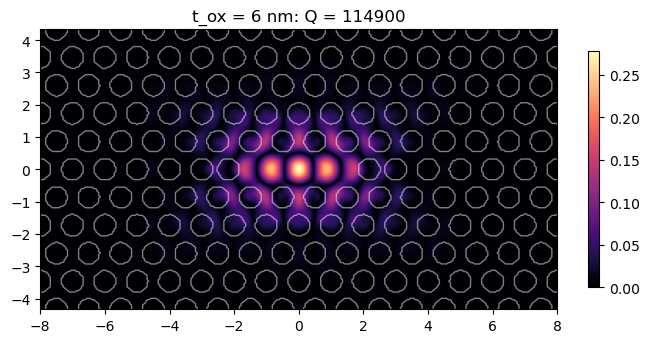

In [93]:
# Single oxidized run (t_ox = 5 nm)
t_ox_test = 6  # nm

mode_idx = 4
phc_ox = cavity_oxidized(t_ox_test, r_nm=77)
gme_ox = legume.GuidedModeExp(phc_ox, gmax=gmax, truncate_g=truncate_g)
gme_ox.run(kpoints=np.array([[0], [0]]), **options)

(freq_im_ox, _, _) = gme_ox.compute_rad(0, [mode_idx])
Q_ox = gme_ox.freqs[0, mode_idx] / (2 * freq_im_ox[0])
f_ox = gme_ox.freqs[0, mode_idx]

print(f't_ox = {t_ox_test} nm:  f = {f_ox:.5f},  Q = {Q_ox:.1f}')
print(f'Change from baseline:  \u0394f = {f_ox - f_base:.5f},  \u0394Q = {Q_ox - Q_base:.1f}')

ax = legume.viz.field(gme_ox, 'e', 0, mode_idx, z=dslab/2,
                      component='y', val='abs', N1=300, N2=200)
plt.title(f't_ox = {t_ox_test} nm: Q = {Q_ox:.0f}')
plt.show()

## Q factor vs oxide thickness

In [77]:
# Sweep oxide thickness (consume_ratio = 0.5)
t_ox_values = np.linspace(0, 10, 21)  # nm
Qs_full = []
freqs_full = []

options_sweep = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                 'gradients': 'approx', 'compute_im': False}

f_prev = f_base  # seed tracking with baseline L3 frequency

print('Sweeping oxide thickness (consume_ratio = 0.5):')
for t_ox_nm in t_ox_values:
    phc_s = cavity_oxidized(t_ox_nm)
    gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
    gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep)

    # Track the L3 mode by frequency continuity
    all_freqs = gme_s.freqs[0, :]
    mind = int(np.argmin(np.abs(all_freqs - f_prev)))

    (freq_im_s, _, _) = gme_s.compute_rad(0, [mind])
    Q_s = gme_s.freqs[0, mind] / (2 * freq_im_s[0])
    f_s = gme_s.freqs[0, mind]

    f_prev = f_s  # update reference for next step

    Qs_full.append(Q_s)
    freqs_full.append(f_s)
    print(f'  t_ox = {t_ox_nm:5.2f} nm,  Q = {Q_s:10.1f},  f = {f_s:.5f}  (mode {mind})')

print('Sweep complete.')

Sweeping oxide thickness (consume_ratio = 0.5):
  t_ox =  0.00 nm,  Q =   198852.0,  f = 0.25754  (mode 8)
  t_ox =  0.50 nm,  Q =   196769.1,  f = 0.25776  (mode 8)
  t_ox =  1.00 nm,  Q =   194487.9,  f = 0.25799  (mode 8)
  t_ox =  1.50 nm,  Q =   192011.0,  f = 0.25822  (mode 8)
  t_ox =  2.00 nm,  Q =   189342.5,  f = 0.25845  (mode 8)
  t_ox =  2.50 nm,  Q =   186488.5,  f = 0.25868  (mode 8)
  t_ox =  3.00 nm,  Q =   183456.4,  f = 0.25892  (mode 8)
  t_ox =  3.50 nm,  Q =   180255.5,  f = 0.25916  (mode 8)
  t_ox =  4.00 nm,  Q =   176896.3,  f = 0.25940  (mode 8)
  t_ox =  4.50 nm,  Q =   173391.1,  f = 0.25964  (mode 8)
  t_ox =  5.00 nm,  Q =   169752.8,  f = 0.25988  (mode 8)
  t_ox =  5.50 nm,  Q =   165995.6,  f = 0.26013  (mode 8)
  t_ox =  6.00 nm,  Q =   162134.6,  f = 0.26037  (mode 8)
  t_ox =  6.50 nm,  Q =   158185.3,  f = 0.26062  (mode 8)
  t_ox =  7.00 nm,  Q =   154163.5,  f = 0.26088  (mode 8)
  t_ox =  7.50 nm,  Q =   150085.1,  f = 0.26113  (mode 8)
  t_ox =

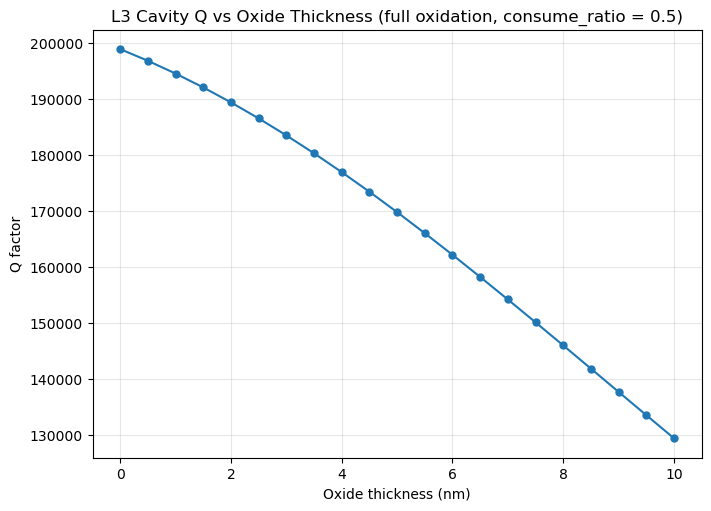

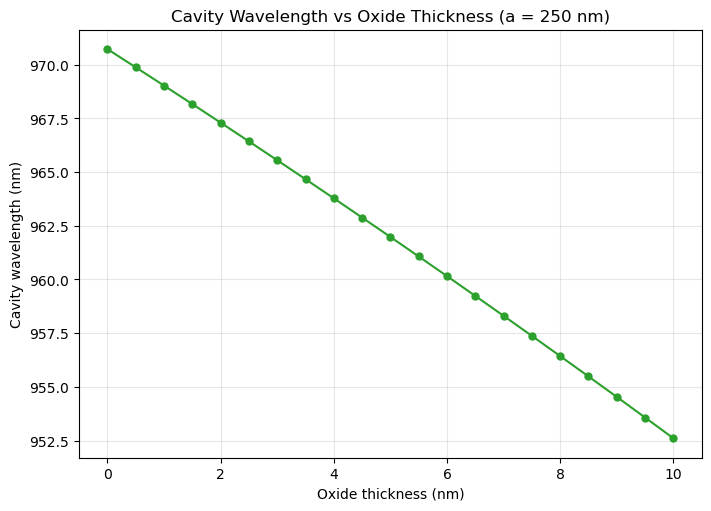

 t_ox (nm)           Q    f (norm)      λ (nm)
-----------------------------------------------------------------
      0.00    198852.0     0.25754       970.7
      0.50    196769.1     0.25776       969.9
      1.00    194487.9     0.25799       969.0
      1.50    192011.0     0.25822       968.2
      2.00    189342.5     0.25845       967.3
      2.50    186488.5     0.25868       966.4
      3.00    183456.4     0.25892       965.6
      3.50    180255.5     0.25916       964.7
      4.00    176896.3     0.25940       963.8
      4.50    173391.1     0.25964       962.9
      5.00    169752.8     0.25988       962.0
      5.50    165995.6     0.26013       961.1
      6.00    162134.6     0.26037       960.2
      6.50    158185.3     0.26062       959.2
      7.00    154163.5     0.26088       958.3
      7.50    150085.1     0.26113       957.4
      8.00    145966.3     0.26139       956.4
      8.50    141822.5     0.26165       955.5
      9.00    137669.1     0.26191       

In [78]:
# ── Plot full-oxidation sweep results ──────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(7, 5), constrained_layout=True)

ax1.plot(t_ox_values, Qs_full, 'o-', lw=1.5, markersize=5)
ax1.set_xlabel('Oxide thickness (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('L3 Cavity Q vs Oxide Thickness (full oxidation, consume_ratio = 0.5)')
ax1.grid(True, alpha=0.3)
plt.show()

# ── Wavelength conversion ──────────────────────────────────────────────────
lambdas_full_nm = [a_nm / f for f in freqs_full]

fig, ax2 = plt.subplots(figsize=(7, 5), constrained_layout=True)
ax2.plot(t_ox_values, lambdas_full_nm, 'o-', lw=1.5, markersize=5, color='tab:green')
ax2.set_xlabel('Oxide thickness (nm)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Cavity Wavelength vs Oxide Thickness (a = {a_nm} nm)')
ax2.grid(True, alpha=0.3)
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print('=' * 65)
print(f'{"t_ox (nm)":>10}  {"Q":>10}  {"f (norm)":>10}  {"λ (nm)":>10}')
print('-' * 65)
for t, q, f, lam in zip(t_ox_values, Qs_full, freqs_full, lambdas_full_nm):
    print(f'{t:>10.2f}  {q:>10.1f}  {f:>10.5f}  {lam:>10.1f}')
print('=' * 65)

## Combined sweep: Q vs oxide thickness for different hole radii

In [79]:
# Combined sweep: oxide thickness for each hole radius
r_nm_list = [73, 74, 75, 76, 77]  # nm
t_ox_vals = np.linspace(0, 10, 21)  # nm
results = {}  # {r_nm: {'Qs': [...], 'freqs': [...]}}

options_sweep2 = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                  'gradients': 'approx', 'compute_im': False}

for r_nm in r_nm_list:
    Qs, freqs = [], []
    f_prev = f_base  # re-seed for each radius

    print(f'\n--- r = {r_nm} nm ---')
    for t_ox_nm in t_ox_vals:
        phc_s = cavity_oxidized(t_ox_nm, r_nm=r_nm)
        gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
        gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep2)

        # Q-based mode selection: find candidates near f_prev, pick highest Q
        all_freqs = gme_s.freqs[0, :]
        candidates = np.where(np.abs(all_freqs - f_prev) < 0.02)[0]
        best_Q, mind = -1, 0
        for c in candidates:
            (fim, _, _) = gme_s.compute_rad(0, [c])
            Qc = gme_s.freqs[0, c] / (2 * fim[0])
            if Qc > best_Q:
                best_Q, mind = Qc, c

        f_s = gme_s.freqs[0, mind]
        f_prev = f_s
        Qs.append(best_Q)
        freqs.append(f_s)
        print(f'  t_ox = {t_ox_nm:5.2f} nm,  Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

    results[r_nm] = {'Qs': Qs, 'freqs': freqs}

print('\nCombined sweep complete.')


--- r = 73 nm ---
  t_ox =  0.00 nm,  Q =   196090.6,  f = 0.25588  (mode 7)
  t_ox =  0.50 nm,  Q =   196265.3,  f = 0.25610  (mode 8)
  t_ox =  1.00 nm,  Q =   196320.9,  f = 0.25633  (mode 8)
  t_ox =  1.50 nm,  Q =   196247.7,  f = 0.25655  (mode 8)
  t_ox =  2.00 nm,  Q =   196036.7,  f = 0.25678  (mode 8)
  t_ox =  2.50 nm,  Q =   195678.7,  f = 0.25700  (mode 8)
  t_ox =  3.00 nm,  Q =   195165.5,  f = 0.25723  (mode 8)
  t_ox =  3.50 nm,  Q =   194489.4,  f = 0.25747  (mode 8)
  t_ox =  4.00 nm,  Q =   193643.5,  f = 0.25770  (mode 8)
  t_ox =  4.50 nm,  Q =   192621.9,  f = 0.25793  (mode 8)
  t_ox =  5.00 nm,  Q =   191419.7,  f = 0.25817  (mode 8)
  t_ox =  5.50 nm,  Q =   190033.4,  f = 0.25841  (mode 8)
  t_ox =  6.00 nm,  Q =   188460.6,  f = 0.25865  (mode 8)
  t_ox =  6.50 nm,  Q =   186700.5,  f = 0.25890  (mode 8)
  t_ox =  7.00 nm,  Q =   184753.8,  f = 0.25914  (mode 8)
  t_ox =  7.50 nm,  Q =   182622.8,  f = 0.25939  (mode 8)
  t_ox =  8.00 nm,  Q =   180311.2,  

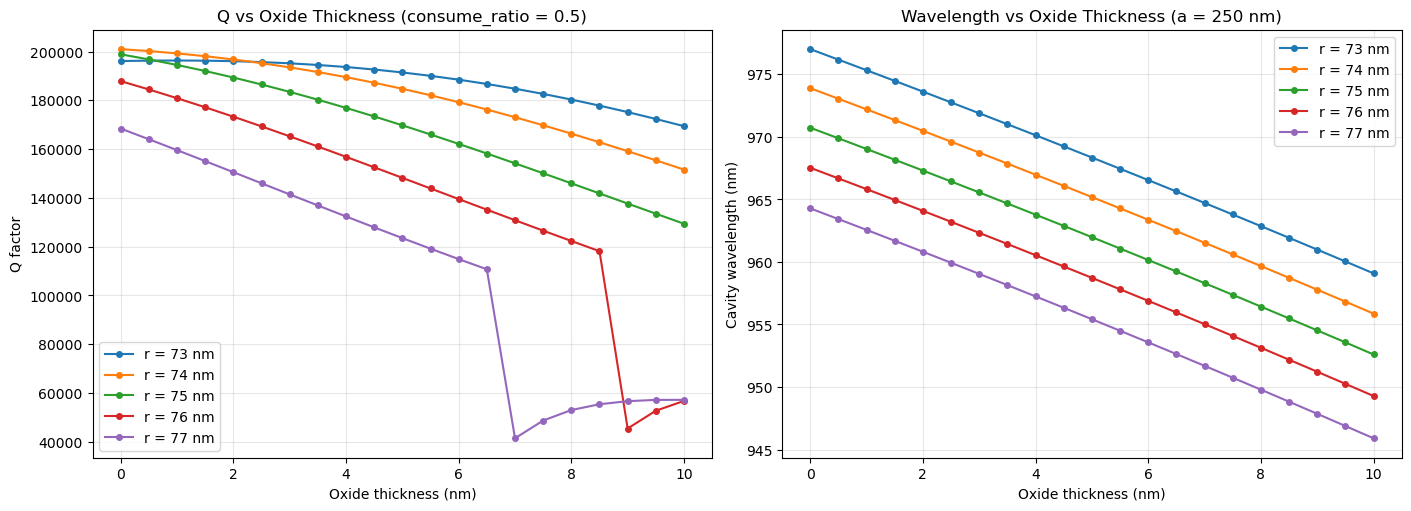

In [80]:
# ── Plot combined sweep results ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for r_nm in r_nm_list:
    ax1.plot(t_ox_vals, results[r_nm]['Qs'], 'o-', ms=4, lw=1.5,
             label=f'r = {r_nm} nm')
    lambdas = [a_nm / f for f in results[r_nm]['freqs']]
    ax2.plot(t_ox_vals, lambdas, 'o-', ms=4, lw=1.5,
             label=f'r = {r_nm} nm')

ax1.set_xlabel('Oxide thickness (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('Q vs Oxide Thickness (consume_ratio = 0.5)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Oxide thickness (nm)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Wavelength vs Oxide Thickness (a = {a_nm} nm)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

## Sweep: Q vs oxide thickness for different consume ratios

In [95]:
# Combined sweep: oxide thickness for each consume_ratio (standard r = 75 nm)
cr_list = np.linspace(0.4, 1.0, 7)  # [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
t_ox_vals_cr = np.linspace(0, 10, 21)  # nm
results_cr = {}  # {cr: {'Qs': [...], 'freqs': [...]}}

options_sweep3 = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                  'gradients': 'approx', 'compute_im': False}

for cr in cr_list:
    Qs, freqs = [], []
    f_prev = f_base

    print(f'\n--- consume_ratio = {cr:.2f} ---')
    for t_ox_nm in t_ox_vals_cr:
        phc_s = cavity_oxidized(t_ox_nm, consume_ratio=cr)
        gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
        gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep3)

        # Q-based mode selection: find candidates near f_prev, pick highest Q
        all_freqs = gme_s.freqs[0, :]
        candidates = np.where(np.abs(all_freqs - f_prev) < 0.02)[0]
        best_Q, mind = -1, 0
        for c in candidates:
            (fim, _, _) = gme_s.compute_rad(0, [c])
            Qc = gme_s.freqs[0, c] / (2 * fim[0])
            if Qc > best_Q:
                best_Q, mind = Qc, c

        f_s = gme_s.freqs[0, mind]
        f_prev = f_s
        Qs.append(best_Q)
        freqs.append(f_s)
        print(f'  t_ox = {t_ox_nm:5.2f} nm,  Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

    results_cr[cr] = {'Qs': Qs, 'freqs': freqs}

print('\nConsume ratio sweep complete.')


--- consume_ratio = 0.40 ---
  t_ox =  0.00 nm,  Q =   198852.0,  f = 0.25754  (mode 8)
  t_ox =  0.50 nm,  Q =   197378.5,  f = 0.25769  (mode 8)
  t_ox =  1.00 nm,  Q =   195814.8,  f = 0.25785  (mode 8)
  t_ox =  1.50 nm,  Q =   194161.1,  f = 0.25800  (mode 8)
  t_ox =  2.00 nm,  Q =   192418.2,  f = 0.25816  (mode 8)
  t_ox =  2.50 nm,  Q =   190587.3,  f = 0.25832  (mode 8)
  t_ox =  3.00 nm,  Q =   188670.1,  f = 0.25848  (mode 8)
  t_ox =  3.50 nm,  Q =   186668.7,  f = 0.25865  (mode 8)
  t_ox =  4.00 nm,  Q =   184585.4,  f = 0.25881  (mode 8)
  t_ox =  4.50 nm,  Q =   182423.3,  f = 0.25898  (mode 8)
  t_ox =  5.00 nm,  Q =   180185.5,  f = 0.25914  (mode 8)
  t_ox =  5.50 nm,  Q =   177875.8,  f = 0.25931  (mode 8)
  t_ox =  6.00 nm,  Q =   175498.0,  f = 0.25948  (mode 8)
  t_ox =  6.50 nm,  Q =   173056.6,  f = 0.25966  (mode 8)
  t_ox =  7.00 nm,  Q =   170556.1,  f = 0.25983  (mode 8)
  t_ox =  7.50 nm,  Q =   168001.4,  f = 0.26001  (mode 8)
  t_ox =  8.00 nm,  Q =   

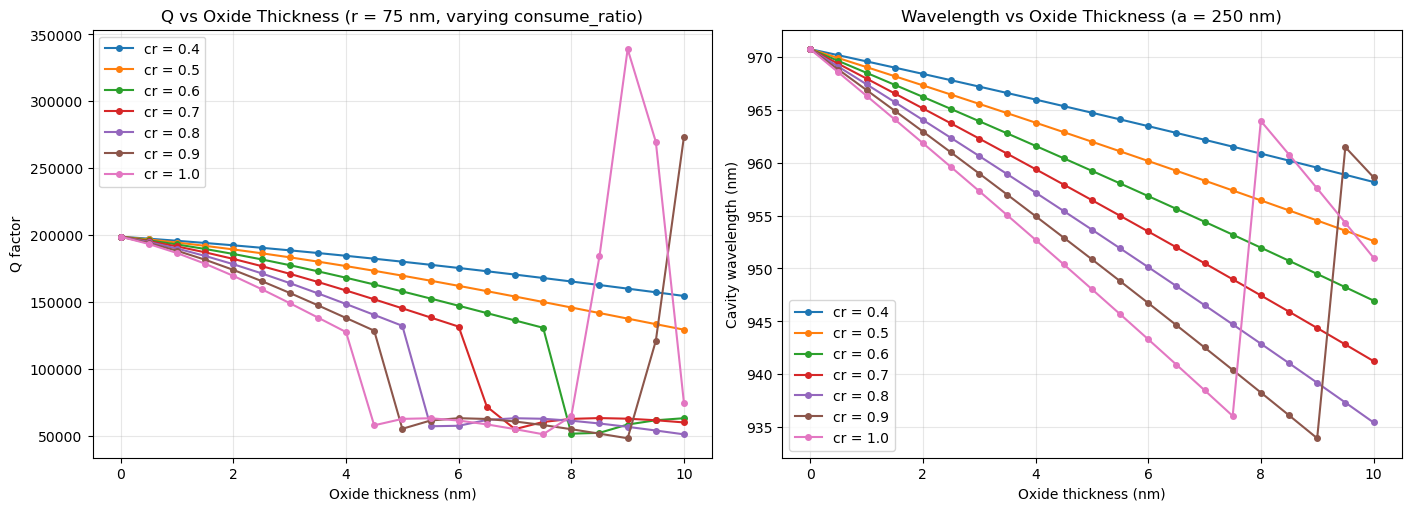

In [96]:
# ── Plot consume_ratio sweep results ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for cr in cr_list:
    label = f'cr = {cr:.1f}'
    ax1.plot(t_ox_vals_cr, results_cr[cr]['Qs'], 'o-', ms=4, lw=1.5, label=label)
    lambdas = [a_nm / f for f in results_cr[cr]['freqs']]
    ax2.plot(t_ox_vals_cr, lambdas, 'o-', ms=4, lw=1.5, label=label)

ax1.set_xlabel('Oxide thickness (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('Q vs Oxide Thickness (r = 75 nm, varying consume_ratio)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Oxide thickness (nm)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Wavelength vs Oxide Thickness (a = {a_nm} nm)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

# Q factor vs hole radius

In [81]:
""" # Sweep hole radius (no oxide)
ra_orig = ra  # save original value
r_nm_values = np.linspace(73, 77, 21)  # nm
Qs_r = []
freqs_r = []

options_r = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
             'gradients': 'approx', 'compute_im': False}

f_prev_r = f_base  # seed tracking with baseline L3 frequency

print('Sweeping hole radius:')
for r_nm in r_nm_values:
    ra = r_nm / a_nm  # update global ra

    phc_r = cavity_oxidized(0)
    gme_r = legume.GuidedModeExp(phc_r, gmax=gmax, truncate_g=truncate_g)
    gme_r.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev_r, **options_r)

    # Track the L3 mode by frequency continuity
    all_freqs_r = gme_r.freqs[0, :]
    mind_r = int(np.argmin(np.abs(all_freqs_r - f_prev_r)))

    (freq_im_r, _, _) = gme_r.compute_rad(0, [mind_r])
    Q_r = gme_r.freqs[0, mind_r] / (2 * freq_im_r[0])
    f_r = gme_r.freqs[0, mind_r]

    f_prev_r = f_r  # update reference for next step

    Qs_r.append(Q_r)
    freqs_r.append(f_r)
    print(f'  r = {r_nm:5.1f} nm (ra = {ra:.4f}),  Q = {Q_r:10.1f},  f = {f_r:.5f}  (mode {mind_r})')

ra = ra_orig  # restore original ra
print('Sweep complete.') """

" # Sweep hole radius (no oxide)\nra_orig = ra  # save original value\nr_nm_values = np.linspace(73, 77, 21)  # nm\nQs_r = []\nfreqs_r = []\n\noptions_r = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,\n             'gradients': 'approx', 'compute_im': False}\n\nf_prev_r = f_base  # seed tracking with baseline L3 frequency\n\nprint('Sweeping hole radius:')\nfor r_nm in r_nm_values:\n    ra = r_nm / a_nm  # update global ra\n\n    phc_r = cavity_oxidized(0)\n    gme_r = legume.GuidedModeExp(phc_r, gmax=gmax, truncate_g=truncate_g)\n    gme_r.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev_r, **options_r)\n\n    # Track the L3 mode by frequency continuity\n    all_freqs_r = gme_r.freqs[0, :]\n    mind_r = int(np.argmin(np.abs(all_freqs_r - f_prev_r)))\n\n    (freq_im_r, _, _) = gme_r.compute_rad(0, [mind_r])\n    Q_r = gme_r.freqs[0, mind_r] / (2 * freq_im_r[0])\n    f_r = gme_r.freqs[0, mind_r]\n\n    f_prev_r = f_r  # update reference for next step\n\n    Qs_r.append(Q_r)\n    

In [82]:
""" # ── Plot radius sweep results ──────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(7, 5), constrained_layout=True)

# Q vs hole radius
ax1.plot(r_nm_values, Qs_r, 'o-', lw=1.5, markersize=5)
ax1.axvline(75, color='gray', ls='--', lw=1, alpha=0.5, label='Nominal (75 nm)')
ax1.set_xlabel('Hole radius (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('L3 Cavity Q vs Hole Radius')
ax1.legend()
ax1.grid(True, alpha=0.3)


plt.show()

# ── Wavelength conversion ──────────────────────────────────────────────────
lambdas_r_nm = [a_nm / f for f in freqs_r]

fig, ax3 = plt.subplots(figsize=(7, 5), constrained_layout=True)
ax3.plot(r_nm_values, lambdas_r_nm, 'o-', lw=1.5, markersize=5, color='tab:green')
ax3.axvline(75, color='gray', ls='--', lw=1, alpha=0.5, label='Nominal (75 nm)')
ax3.set_xlabel('Hole radius (nm)')
ax3.set_ylabel('Cavity wavelength (nm)')
ax3.set_title(f'Cavity Wavelength vs Hole Radius (a = {a_nm} nm)')
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print('=' * 65)
print(f'{"r (nm)":>10}  {"Q":>10}  {"f (norm)":>10}  {"λ (nm)":>10}')
print('-' * 65)
for r, q, f, lam in zip(r_nm_values, Qs_r, freqs_r, lambdas_r_nm):
    print(f'{r:>10.1f}  {q:>10.1f}  {f:>10.5f}  {lam:>10.1f}')
print('=' * 65)

 """

' # ── Plot radius sweep results ──────────────────────────────────────────────\nfig, ax1 = plt.subplots(figsize=(7, 5), constrained_layout=True)\n\n# Q vs hole radius\nax1.plot(r_nm_values, Qs_r, \'o-\', lw=1.5, markersize=5)\nax1.axvline(75, color=\'gray\', ls=\'--\', lw=1, alpha=0.5, label=\'Nominal (75 nm)\')\nax1.set_xlabel(\'Hole radius (nm)\')\nax1.set_ylabel(\'Q factor\')\nax1.set_title(\'L3 Cavity Q vs Hole Radius\')\nax1.legend()\nax1.grid(True, alpha=0.3)\n\n\nplt.show()\n\n# ── Wavelength conversion ──────────────────────────────────────────────────\nlambdas_r_nm = [a_nm / f for f in freqs_r]\n\nfig, ax3 = plt.subplots(figsize=(7, 5), constrained_layout=True)\nax3.plot(r_nm_values, lambdas_r_nm, \'o-\', lw=1.5, markersize=5, color=\'tab:green\')\nax3.axvline(75, color=\'gray\', ls=\'--\', lw=1, alpha=0.5, label=\'Nominal (75 nm)\')\nax3.set_xlabel(\'Hole radius (nm)\')\nax3.set_ylabel(\'Cavity wavelength (nm)\')\nax3.set_title(f\'Cavity Wavelength vs Hole Radius (a = {a_nm}